# Processing results from different VLMs

In [64]:
#imports
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



## Local VLMs for scenario prediction (from frames)

In [65]:
#go through all files that start with 'results_', then turn it into a pandas dataframe,
# #then put everything into a single df where the prediction if the mode of the frames
def load_results(directory):
    results = pd.DataFrame()
    full_results_mode = pd.DataFrame()
    full_results_last = pd.DataFrame()
    for filename in os.listdir(directory):
        if filename.startswith('results_'):
            filepath = os.path.join(directory, filename)
            df = pd.read_csv(filepath)
            #add column in the beginning with the filename without 'results_' and '.csv'
            df['model'] = filename[8:-4]
            #make it first column
            df = df[['model'] + [col for col in df.columns if col != 'model']]

            #group by video_name and take the mode of the predictions
            df_grouped_mode = df.groupby('video_name').agg(lambda x: x.mode()[0] if not x.mode().empty else np.nan).reset_index()
            #add the grouped dataframe to the full results
            full_results_mode = pd.concat([full_results_mode, df_grouped_mode], ignore_index=True)

            # Get last frame prediction for each video
            df_grouped_last = df.sort_values('frame').groupby('video_name').tail(1).reset_index(drop=True)
            full_results_last = pd.concat([full_results_last, df_grouped_last], ignore_index=True)

            results = pd.concat([results, df], ignore_index=True)

    #group by filename, by video, and take the mode of the predictions

    return results, full_results_mode, full_results_last

In [66]:
path = '../results/'
results, full_results_mode, full_results_last = load_results(path)

#remove NaN values from the results
print("Removing NaN values from the results...")
print(results.shape)
#drop rows if 'outcome_prediction' contains word "Error"
results = results[~results['outcome_prediction'].str.contains("Error", na=False)]
print(results.shape)

print("\n" + "="*50)
print("MODE PREDICTIONS")
print("="*50)
print(full_results_mode.shape)
full_results_mode = full_results_mode[~full_results_mode['outcome_prediction'].str.contains("Error", na=False)]
print("Mode results after removing NaN values:")
print(full_results_mode.shape)

print("\n" + "="*50)
print("LAST FRAME PREDICTIONS")
print("="*50)
print(full_results_last.shape)
full_results_last = full_results_last[~full_results_last['outcome_prediction'].str.contains("Error", na=False)]
print("Last frame results after removing NaN values:")
print(full_results_last.shape)
print("types of predictions:", full_results_last['outcome_prediction'].unique())

#save the results to a csv file
results.to_csv('all_predictions.csv', index=False)
#save the mode results to a csv file
full_results_mode.to_csv('all_predictions_mode.csv', index=False)
#save the last frame results to a csv file
full_results_last.to_csv('all_predictions_last.csv', index=False)

#see how many unique videos are for each model
print("\n" + "="*50)
print("Unique videos per model:")
print("="*50)
unique_videos_per_model = results.groupby('model')['video_name'].nunique().reset_index()
print(unique_videos_per_model)

Removing NaN values from the results...
(5301, 4)
(5301, 4)

MODE PREDICTIONS
(270, 4)
Mode results after removing NaN values:
(270, 4)

LAST FRAME PREDICTIONS
(270, 4)
Last frame results after removing NaN values:
(270, 4)
types of predictions: ['Poorly.' 'Well' 'Poorly' 'poorly' 'Well.' 'well']

Unique videos per model:
            model  video_name
0    deepseek_ocr          30
1          gemma3          30
2      gemma3_27b          30
3   llama32vision          30
4           llava          30
5     llavallama3          30
6  mistralsmall32          30
7          qwen25          30
8           qwen3          30


In [67]:
#now, per model, print how many videos are "Poorly" and how many are "Well", accounting for small variations in the writing
print("="*50)
print("MODE PREDICTIONS - Poorly vs Well counts")
print("="*50)
for model in full_results_mode['model'].unique():
    print(f"Model: {model}")
    model_results = full_results_mode[full_results_mode['model'] == model]
    poorly_count = model_results['outcome_prediction'].str.contains('Poorly', case=False, na=False).sum()
    well_count = model_results['outcome_prediction'].str.contains('Well', case=False, na=False).sum()
    print(f"  Poorly: {poorly_count}")
    print(f"  Well: {well_count}")
    #print unique values
    print(model_results['outcome_prediction'].unique())


MODE PREDICTIONS - Poorly vs Well counts
Model: llama32vision
  Poorly: 30
  Well: 0
['Poorly.']
Model: llavallama3
  Poorly: 5
  Well: 25
['Well' 'Poorly']
Model: deepseek_ocr
  Poorly: 4
  Well: 26
['Well' 'poorly' 'Poorly']
Model: gemma3
  Poorly: 30
  Well: 0
['Poorly']
Model: qwen25
  Poorly: 14
  Well: 16
['Well' 'Poorly' 'Well.' 'Poorly.']
Model: mistralsmall32
  Poorly: 30
  Well: 0
['Poorly' 'poorly']
Model: qwen3
  Poorly: 7
  Well: 23
['well' 'poorly']
Model: gemma3_27b
  Poorly: 30
  Well: 0
['Poorly.']
Model: llava
  Poorly: 25
  Well: 5
['Poorly' 'Well']


In [68]:
#for outcome_prediction, replace poorly with 1 and well with 0
#if it contains "poorly", make new list with 1, if it contains "well", make new list with 0
full_results_mode['outcome_prediction_numeric'] = full_results_mode['outcome_prediction'].apply(
    lambda x: 1 if 'poorly' in str(x).lower() else (0 if 'well' in str(x).lower() else np.nan)
)
#print unique results
print(full_results_mode['outcome_prediction_numeric'].unique())


#save the full results with numeric outcome prediction to a csv file
full_results_mode.to_csv('all_predictions_mode.csv', index=False)

full_results_mode

[1 0]


,video_name,model,frame,outcome_prediction,outcome_prediction_numeric
0,11_final.mp4,llama32vision,0,Poorly.,1
1,12_final.mp4,llama32vision,0,Poorly.,1
2,14_final.mp4,llama32vision,0,Poorly.,1
3,15_final.mp4,llama32vision,0,Poorly.,1
4,19_final.mp4,llama32vision,0,Poorly.,1
...,...,...,...,...,...
265,59_final.mp4,llava,0,Well,0
266,60_final.mp4,llava,0,Poorly,1
267,6_final.mp4,llava,0,Poorly,1
268,7_final.mp4,llava,0,Poorly,1


In [69]:
#now, get the groundtruth and see if they got it right
#open csv with columns Video,Question Mapping,Average Class of Human Predicion,True Outcome,

gt_df = pd.read_csv('../../../dataset_scenarios/analyze_predictions.csv')

#map each video to its true outcome
gt_df = gt_df[['Video', 'True Outcome']].rename(columns={'Video': 'video_name', 'True Outcome': 'true_outcome'})
#video are name without the .mp4 extension, so we need to add it to each one
gt_df['video_name'] = gt_df['video_name'].apply(lambda x: x + '.mp4' if not x.endswith('.mp4') else x)
#print type of true_outcome
gt_df['true_outcome'] = gt_df['true_outcome'].astype(int)
#dictionary to map video names to true outcomes
gt_dict = dict(zip(gt_df['video_name'], gt_df['true_outcome']))

#add the "true_outcome" column to the full_results_mode dataframe
full_results_mode['true_outcome'] = full_results_mode['video_name'].map(gt_dict)

#add the "true_outcome" column to the full_results_last dataframe
full_results_last['outcome_prediction_numeric'] = full_results_last['outcome_prediction'].apply(
    lambda x: 1 if 'poorly' in str(x).lower() else (0 if 'well' in str(x).lower() else np.nan)
)
#print unique results
print(full_results_last['outcome_prediction_numeric'].unique())
#check if there are nan
print(full_results_last['outcome_prediction_numeric'].isna().sum())


full_results_last['true_outcome'] = full_results_last['video_name'].map(gt_dict)

print("Mode results with ground truth:")
print(full_results_mode.head())
print("\nLast frame results with ground truth:")
print(full_results_last.head())

[1 0]
0
Mode results with ground truth:
     video_name          model  frame outcome_prediction  \
0  11_final.mp4  llama32vision      0            Poorly.   
1  12_final.mp4  llama32vision      0            Poorly.   
2  14_final.mp4  llama32vision      0            Poorly.   
3  15_final.mp4  llama32vision      0            Poorly.   
4  19_final.mp4  llama32vision      0            Poorly.   

   outcome_prediction_numeric  true_outcome  
0                           1             1  
1                           1             1  
2                           1             1  
3                           1             1  
4                           1             0  

Last frame results with ground truth:
           model    video_name  frame outcome_prediction  \
0  llama32vision   6_final.mp4    180            Poorly.   
1  llama32vision  22_final.mp4    195            Poorly.   
2  llama32vision  34_final.mp4    210            Poorly.   
3  llama32vision  12_final.mp4    210       

In [70]:
# ===================================================================
# MODE PREDICTIONS PERFORMANCE vs Ground Truth
# ===================================================================
print("="*50)
print("MODE PREDICTIONS PERFORMANCE vs Ground Truth")
print("="*50)

#models and metrics df
prediction_performance_mode_df = pd.DataFrame(columns=['model', 'accuracy', 'precision', 'recall', 'f1_score', 'poorly_ratio'])

#now, go video by video and see if the model got it right
correct_predictions = []
for model in full_results_mode['model'].unique():
    model_results = full_results_mode[full_results_mode['model'] == model]
    y_pred = model_results['outcome_prediction_numeric']
    y_true = []
    for index, row in model_results.iterrows():
        video_name = row['video_name']
        true_outcome = gt_dict.get(video_name, np.nan)
        y_true.append(true_outcome)

    
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)

    #get accuracy, precision, recall, f1 score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Calculate poorly ratio (ratio of poorly/0 predictions to all predictions)
    poorly_count = (y_pred == 1).sum()  # 1 represents "poorly" in our encoding
    total_count = len(y_pred)
    poorly_ratio = poorly_count / total_count if total_count > 0 else 0

    print(f"Model: {model}")
    print(f"  Accuracy: {accuracy:.2f}")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1 Score: {f1:.2f}")
    print(f"  Poorly Ratio: {poorly_ratio:.2f}")

    df_pred = pd.DataFrame({
        'model': [model],
        'accuracy': [accuracy],
        'precision': [precision],
        'recall': [recall],
        'f1_score': [f1],
        'poorly_ratio': [poorly_ratio]
    })
    prediction_performance_mode_df = pd.concat([prediction_performance_mode_df, df_pred], ignore_index=True)

#save the prediction performance to a csv file
prediction_performance_mode_df.to_csv('prediction_performance_mode.csv', index=False)
#save full results with true outcome to a csv file
full_results_mode.to_csv('all_predictions_mode_with_true_outcome.csv', index=False)

prediction_performance_mode_df

MODE PREDICTIONS PERFORMANCE vs Ground Truth
Model: llama32vision
  Accuracy: 0.43
  Precision: 0.43
  Recall: 1.00
  F1 Score: 0.60
  Poorly Ratio: 1.00
Model: llavallama3
  Accuracy: 0.53
  Precision: 0.40
  Recall: 0.15
  F1 Score: 0.22
  Poorly Ratio: 0.17
Model: deepseek_ocr
  Accuracy: 0.50
  Precision: 0.25
  Recall: 0.08
  F1 Score: 0.12
  Poorly Ratio: 0.13
Model: gemma3
  Accuracy: 0.43
  Precision: 0.43
  Recall: 1.00
  F1 Score: 0.60
  Poorly Ratio: 1.00
Model: qwen25
  Accuracy: 0.50
  Precision: 0.43
  Recall: 0.46
  F1 Score: 0.44
  Poorly Ratio: 0.47
Model: mistralsmall32
  Accuracy: 0.43
  Precision: 0.43
  Recall: 1.00
  F1 Score: 0.60
  Poorly Ratio: 1.00
Model: qwen3
  Accuracy: 0.47
  Precision: 0.29
  Recall: 0.15
  F1 Score: 0.20
  Poorly Ratio: 0.23
Model: gemma3_27b
  Accuracy: 0.43
  Precision: 0.43
  Recall: 1.00
  F1 Score: 0.60
  Poorly Ratio: 1.00
Model: llava
  Accuracy: 0.33
  Precision: 0.36
  Recall: 0.69
  F1 Score: 0.47
  Poorly Ratio: 0.83


/tmp/ipykernel_3157940/1376771974.py:52: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prediction_performance_mode_df = pd.concat([prediction_performance_mode_df, df_pred], ignore_index=True)


,model,accuracy,precision,recall,f1_score,poorly_ratio
0,llama32vision,0.433333,0.433333,1.000000,0.604651,1.000000
1,llavallama3,0.533333,0.400000,0.153846,0.222222,0.166667
2,deepseek_ocr,0.500000,0.250000,0.076923,0.117647,0.133333
3,gemma3,0.433333,0.433333,1.000000,0.604651,1.000000
4,qwen25,0.500000,0.428571,0.461538,0.444444,0.466667
5,mistralsmall32,0.433333,0.433333,1.000000,0.604651,1.000000
6,qwen3,0.466667,0.285714,0.153846,0.200000,0.233333
7,gemma3_27b,0.433333,0.433333,1.000000,0.604651,1.000000
8,llava,0.333333,0.360000,0.692308,0.473684,0.833333


In [71]:
# ===================================================================
# LAST FRAME PREDICTIONS PERFORMANCE vs Ground Truth
# ===================================================================
print("\n" + "="*50)
print("LAST FRAME PREDICTIONS PERFORMANCE vs Ground Truth")
print("="*50)

#models and metrics df
prediction_performance_last_df = pd.DataFrame(columns=['model', 'accuracy', 'precision', 'recall', 'f1_score', 'poorly_ratio'])

#now, go video by video and see if the model got it right
for model in full_results_last['model'].unique():
    model_results = full_results_last[full_results_last['model'] == model]
    y_pred = model_results['outcome_prediction_numeric']
    #if has NaN values, print it and print video name
    if y_pred.isna().any():
        print(f"Model {model} has NaN values in predictions for videos:")
        print(model_results[model_results['outcome_prediction_numeric'].isna()]['video_name'].tolist())
    y_true = []
    for index, row in model_results.iterrows():
        video_name = row['video_name']
        true_outcome = gt_dict.get(video_name, np.nan)
        y_true.append(true_outcome)

    
    y_pred = np.array(y_pred)
    y_true = np.array(y_true)
    #chek if y
    #print('count of each type in y_pred:', np.bincount(y_pred.astype(int)))
    #print('count of each type in y_true:', np.bincount(y_true))

    #get accuracy, precision, recall, f1 score
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    # Calculate poorly ratio (ratio of poorly/0 predictions to all predictions)
    poorly_count = (y_pred == 1).sum()  # 1 represents "poorly" in our encoding
    total_count = len(y_pred)
    poorly_ratio = poorly_count / total_count if total_count > 0 else 0

    print(f"Model: {model}")
    print(f"  Accuracy: {accuracy:.2f}")
    print(f"  Precision: {precision:.2f}")
    print(f"  Recall: {recall:.2f}")
    print(f"  F1 Score: {f1:.2f}")
    print(f"  Poorly Ratio: {poorly_ratio:.2f}")

    df_pred = pd.DataFrame({
        'model': [model],
        'accuracy': [accuracy],
        'precision': [precision],
        'recall': [recall],
        'f1_score': [f1],
        'poorly_ratio': [poorly_ratio]
    })
    prediction_performance_last_df = pd.concat([prediction_performance_last_df, df_pred], ignore_index=True)

#save the prediction performance to a csv file
prediction_performance_last_df.to_csv('prediction_performance_last.csv', index=False)
#save full results with true outcome to a csv file
full_results_last.to_csv('all_predictions_last_with_true_outcome.csv', index=False)

prediction_performance_last_df


LAST FRAME PREDICTIONS PERFORMANCE vs Ground Truth
Model: llama32vision
  Accuracy: 0.43
  Precision: 0.43
  Recall: 1.00
  F1 Score: 0.60
  Poorly Ratio: 1.00
Model: llavallama3
  Accuracy: 0.50
  Precision: 0.38
  Recall: 0.23
  F1 Score: 0.29
  Poorly Ratio: 0.27
Model: deepseek_ocr
  Accuracy: 0.43
  Precision: 0.25
  Recall: 0.15
  F1 Score: 0.19
  Poorly Ratio: 0.27
Model: gemma3
  Accuracy: 0.43
  Precision: 0.43
  Recall: 1.00
  F1 Score: 0.60
  Poorly Ratio: 1.00
Model: qwen25
  Accuracy: 0.53
  Precision: 0.46
  Recall: 0.46
  F1 Score: 0.46
  Poorly Ratio: 0.43
Model: mistralsmall32
  Accuracy: 0.43
  Precision: 0.43
  Recall: 1.00
  F1 Score: 0.60
  Poorly Ratio: 1.00
Model: qwen3
  Accuracy: 0.43
  Precision: 0.25
  Recall: 0.15
  F1 Score: 0.19
  Poorly Ratio: 0.27
Model: gemma3_27b
  Accuracy: 0.43
  Precision: 0.43
  Recall: 1.00
  F1 Score: 0.60
  Poorly Ratio: 1.00
Model: llava
  Accuracy: 0.37
  Precision: 0.38
  Recall: 0.69
  F1 Score: 0.49
  Poorly Ratio: 0.80


/tmp/ipykernel_3157940/4009274023.py:58: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  prediction_performance_last_df = pd.concat([prediction_performance_last_df, df_pred], ignore_index=True)


,model,accuracy,precision,recall,f1_score,poorly_ratio
0,llama32vision,0.433333,0.433333,1.000000,0.604651,1.000000
1,llavallama3,0.500000,0.375000,0.230769,0.285714,0.266667
2,deepseek_ocr,0.433333,0.250000,0.153846,0.190476,0.266667
3,gemma3,0.433333,0.433333,1.000000,0.604651,1.000000
4,qwen25,0.533333,0.461538,0.461538,0.461538,0.433333
5,mistralsmall32,0.433333,0.433333,1.000000,0.604651,1.000000
6,qwen3,0.433333,0.250000,0.153846,0.190476,0.266667
7,gemma3_27b,0.433333,0.433333,1.000000,0.604651,1.000000
8,llava,0.366667,0.375000,0.692308,0.486486,0.800000


In [72]:
# ===================================================================
# Load Human Predictions and Setup for Model-Human Comparison
# ===================================================================
print("\n" + "="*50)
print("Loading Human Predictions and Setting up Mappings")
print("="*50)

# Load human predictions data
human_df = pd.read_csv('../../../dataset_scenarios/badidea_ground_truth.csv')

# Filter to only include specific participant IDs
valid_participant_ids = [1048, 1251, 1483, 1676, 2103, 2313, 2698, 2946, 3157, 3203, 3339, 3882, 5009, 5099, 5124, 5233, 5310, 6488, 7136, 7782, 7797, 8184, 8436, 8758, 8786, 9055, 9385, 9777, 9941]
print(f"Filtering to only include {len(valid_participant_ids)} specific participants")
print(f"Original human dataset size: {len(human_df)}")
human_df = human_df[human_df['participant_id'].isin(valid_participant_ids)]
print(f"Filtered human dataset size: {len(human_df)}")

# Get unique participant IDs (now filtered)
participant_ids = human_df['participant_id'].unique()
print(f"Number of participants after filtering: {len(participant_ids)}")

# Define metrics calculation function
def calculate_metrics(y_true, y_pred_prob):
    from sklearn.metrics import roc_auc_score

    # Convert to binary if needed
    y_pred = (np.array(y_pred_prob) >= 0.5).astype(int)
    y_true = np.array(y_true).astype(int)

    # Handle cases where only one class is present
    try:
        auc = roc_auc_score(y_true, y_pred_prob)
    except:
        auc = np.nan

    # Calculate metrics
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'auc': auc,
        'mse': np.mean((y_true - y_pred_prob) ** 2),
        'mae': np.mean(np.abs(y_true - y_pred_prob))
    }
    return metrics

# Calculate average human metrics for reference
print("\nCalculating human baseline metrics...")

# Use the correct mapping from question format to video format  
gt_df_full = pd.read_csv('../../../dataset_scenarios/analyze_predictions.csv')
question_to_outcome = dict(zip(gt_df_full['Question Mapping'], gt_df_full['True Outcome']))

# Calculate metrics for each individual human participant
human_metrics = {}
for participant_id in participant_ids:
    participant_data = human_df[human_df['participant_id'] == participant_id]
    
    true_outcomes = []
    participant_predictions = []
    
    for _, row in participant_data.iterrows():
        question_id = row['response_video']  # This is already in q_X format
        
        if question_id in question_to_outcome:
            true_outcomes.append(question_to_outcome[question_id])
            participant_predictions.append(row['class'])

    if len(true_outcomes) > 0:
        human_metrics[participant_id] = calculate_metrics(
            np.array(true_outcomes),
            np.array(participant_predictions)
        )

# Calculate average metrics across all participants
avg_human_metrics = {}
for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc', 'mse', 'mae']:
    values = [m[metric] for m in human_metrics.values() if not np.isnan(m[metric])]
    avg_human_metrics[metric] = np.mean(values) if values else np.nan

print(f"Human baseline calculated from {len(human_metrics)} participants")

# Read the ground truth file again to get the proper mapping
gt_df_full = pd.read_csv('../../../dataset_scenarios/analyze_predictions.csv')

# Create mapping from question format (q_X) to video format (X_final.mp4)
question_to_video = dict(zip(gt_df_full['Question Mapping'], gt_df_full['Video']))
print("Question to Video mapping (sample):")
for i, (q, v) in enumerate(list(question_to_video.items())[:5]):
    print(f"   {q} -> {v}")

# Create the reverse mapping: video format to question format
video_to_question = {v + '.mp4': q for q, v in question_to_video.items()}
print("\nVideo to Question mapping (sample):")
for i, (v, q) in enumerate(list(video_to_question.items())[:5]):
    print(f"   {v} -> {q}")

# Test the mapping with actual model data
print("\nTesting the fixed mapping:")
sample_videos = list(full_results_mode['video_name'].unique())[:3]
print("   Sample model videos:", sample_videos)
print("   Corresponding question IDs:", [video_to_question.get(v, "NOT FOUND") for v in sample_videos])


Loading Human Predictions and Setting up Mappings
Filtering to only include 29 specific participants
Original human dataset size: 865
Filtered human dataset size: 865
Number of participants after filtering: 29

Calculating human baseline metrics...
Human baseline calculated from 29 participants
Question to Video mapping (sample):
   q_2 -> 6_final
   q_3 -> 7_final
   q_4 -> 9_final
   q_5 -> 11_final
   q_6 -> 12_final

Video to Question mapping (sample):
   6_final.mp4 -> q_2
   7_final.mp4 -> q_3
   9_final.mp4 -> q_4
   11_final.mp4 -> q_5
   12_final.mp4 -> q_6

Testing the fixed mapping:
   Sample model videos: ['11_final.mp4', '12_final.mp4', '14_final.mp4']
   Corresponding question IDs: ['q_5', 'q_6', 'q_7']


In [73]:
# ===================================================================
# Local Models vs Individual Human Predictions - MODE PREDICTIONS
# ===================================================================
print("\n" + "="*50)
print("MODE PREDICTIONS vs Individual Human Predictions")
print("="*50)

# Debug: Check what we have
print("Debug - Available data:")
print(f"full_results_mode shape: {full_results_mode.shape}")
print(f"full_results_mode columns: {full_results_mode.columns.tolist()}")
print(f"Models in full_results_mode: {full_results_mode['model'].unique()}")

# Check for NaN values in predictions
print(f"NaN values in outcome_prediction_numeric: {full_results_mode['outcome_prediction_numeric'].isna().sum()}")
print(f"Non-NaN values in outcome_prediction_numeric: {full_results_mode['outcome_prediction_numeric'].notna().sum()}")

# Use the video_to_question mapping from the previous cell
# Create a mapping from video name to model predictions (MODE)
video_to_model_preds_mode = {}
for model in full_results_mode['model'].unique():
    model_data = full_results_mode[full_results_mode['model'] == model]
    print(f"\nModel {model} - before filtering:")
    print(f"  Total rows: {len(model_data)}")
    print(f"  Rows with outcome_prediction_numeric: {model_data['outcome_prediction_numeric'].notna().sum()}")
    
    # Remove NaN values from model predictions
    model_data_clean = model_data.dropna(subset=['outcome_prediction_numeric'])
    print(f"  After dropping NaN: {len(model_data_clean)}")
    
    # Check for actual values
    if len(model_data_clean) > 0:
        print(f"  Sample predictions: {model_data_clean['outcome_prediction_numeric'].head().tolist()}")
        print(f"  Unique predictions: {model_data_clean['outcome_prediction_numeric'].unique()}")
    
    video_to_model_preds_mode[model] = dict(zip(model_data_clean['video_name'], model_data_clean['outcome_prediction_numeric']))
    print(f"  Valid predictions in mapping: {len(video_to_model_preds_mode[model])}")

# Calculate metrics for each model compared to each participant
model_vs_human_metrics_mode = {}

for model in full_results_mode['model'].unique():
    model_vs_human_metrics_mode[model] = {}
    print(f"\nProcessing model: {model}")
    
    model_pred_count = 0
    total_matches = 0
    
    for participant_id in participant_ids:
        # Get this participant's predictions
        participant_data = human_df[human_df['participant_id'] == participant_id]
        
        # Create lists to store participant predictions and model predictions
        human_preds = []
        model_preds = []
        
        # Match participant responses with model predictions using the mapping
        for _, row in participant_data.iterrows():
            question_id = row['response_video']  # e.g., 'q_2'
            
            # Convert question ID to video name using the mapping
            if question_id in question_to_video:
                video_name = question_to_video[question_id] + '.mp4'  # Convert to video format
                
                # Check if this video has a model prediction
                if video_name in video_to_model_preds_mode[model]:
                    model_pred = video_to_model_preds_mode[model][video_name]
                    if not np.isnan(model_pred):
                        human_preds.append(row['class'])
                        model_preds.append(model_pred)
                        total_matches += 1
        
        model_pred_count += len(human_preds)
        
        # Calculate metrics if this participant has matching predictions
        if len(human_preds) > 0:
            print(f"   Participant {participant_id}: {len(human_preds)} matching predictions")
            try:
                model_vs_human_metrics_mode[model][participant_id] = calculate_metrics(
                    np.array(human_preds),
                    np.array(model_preds)
                )
            except Exception as e:
                print(f"   Error calculating metrics for participant {participant_id}: {e}")
        else:
            print(f"   Participant {participant_id}: No matching predictions")
    
    print(f"   Total matches for {model}: {total_matches}")

# Calculate average metrics for each model vs humans
avg_model_vs_human_mode = {}
std_model_vs_human_mode = {}
for model, participant_metrics in model_vs_human_metrics_mode.items():
    if participant_metrics:  # Only if there are metrics for this model
        avg_model_vs_human_mode[model] = {}
        std_model_vs_human_mode[model] = {}
        for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc', 'mse', 'mae']:
            values = [m[metric] for m in participant_metrics.values() if not np.isnan(m[metric])]
            avg_model_vs_human_mode[model][metric] = np.mean(values) if values else np.nan
            std_model_vs_human_mode[model][metric] = np.std(values) if values else np.nan

# Convert to DataFrame for easier comparison
if avg_model_vs_human_mode:
    avg_model_vs_human_mode_df = pd.DataFrame(avg_model_vs_human_mode).T
    print("\n" + "="*50)
    print("RESULTS: MODE - Average Agreement with Individual Humans")
    print("="*50)
    print(avg_model_vs_human_mode_df.round(3))
    
    std_model_vs_human_mode_df = pd.DataFrame(std_model_vs_human_mode).T
    print("\nStandard Deviation of Agreement with Individual Humans:")
    print(std_model_vs_human_mode_df.round(3))
    
    # Save results
    avg_model_vs_human_mode_df.to_csv('model_vs_human_agreement_mode.csv')
    print("\nResults saved to 'model_vs_human_agreement_mode.csv'")
else:
    print("\n❌ No valid metrics calculated - check data alignment issues")


MODE PREDICTIONS vs Individual Human Predictions
Debug - Available data:
full_results_mode shape: (270, 6)
full_results_mode columns: ['video_name', 'model', 'frame', 'outcome_prediction', 'outcome_prediction_numeric', 'true_outcome']
Models in full_results_mode: ['llama32vision' 'llavallama3' 'deepseek_ocr' 'gemma3' 'qwen25'
 'mistralsmall32' 'qwen3' 'gemma3_27b' 'llava']
NaN values in outcome_prediction_numeric: 0
Non-NaN values in outcome_prediction_numeric: 270

Model llama32vision - before filtering:
  Total rows: 30
  Rows with outcome_prediction_numeric: 30
  After dropping NaN: 30
  Sample predictions: [1, 1, 1, 1, 1]
  Unique predictions: [1]
  Valid predictions in mapping: 30

Model llavallama3 - before filtering:
  Total rows: 30
  Rows with outcome_prediction_numeric: 30
  After dropping NaN: 30
  Sample predictions: [0, 0, 0, 0, 0]
  Unique predictions: [0 1]
  Valid predictions in mapping: 30

Model deepseek_ocr - before filtering:
  Total rows: 30
  Rows with outcome_pr

In [74]:
# ===================================================================
# Local Models vs Individual Human Predictions - LAST FRAME PREDICTIONS
# ===================================================================
print("\n" + "="*50)
print("LAST FRAME PREDICTIONS vs Individual Human Predictions")
print("="*50)

# Use the video_to_question mapping from the previous cell
# Create a mapping from video name to model predictions (LAST FRAME)
video_to_model_preds_last = {}
for model in full_results_last['model'].unique():
    model_data = full_results_last[full_results_last['model'] == model]
    # Remove NaN values from model predictions
    model_data_clean = model_data.dropna(subset=['outcome_prediction_numeric'])
    video_to_model_preds_last[model] = dict(zip(model_data_clean['video_name'], model_data_clean['outcome_prediction_numeric']))
    print(f"Model {model}: {len(video_to_model_preds_last[model])} valid predictions")

# Calculate metrics for each model compared to each participant
model_vs_human_metrics_last = {}

for model in full_results_last['model'].unique():
    model_vs_human_metrics_last[model] = {}
    print(f"\nProcessing model: {model}")
    
    for participant_id in participant_ids:
        # Get this participant's predictions
        participant_data = human_df[human_df['participant_id'] == participant_id]
        
        # Create lists to store participant predictions and model predictions
        human_preds = []
        model_preds = []
        
        # Match participant responses with model predictions using the mapping
        for _, row in participant_data.iterrows():
            question_id = row['response_video']  # e.g., 'q_2'
            
            # Convert question ID to video name using the mapping
            if question_id in question_to_video:
                video_name = question_to_video[question_id] + '.mp4'  # Convert to video format
                
                # Check if this video has a model prediction
                if video_name in video_to_model_preds_last[model]:
                    model_pred = video_to_model_preds_last[model][video_name]
                    if not np.isnan(model_pred):
                        human_preds.append(row['class'])
                        model_preds.append(model_pred)
        
        # Calculate metrics if this participant has matching predictions
        if len(human_preds) > 0:
            print(f"   Participant {participant_id}: {len(human_preds)} matching predictions")
            try:
                model_vs_human_metrics_last[model][participant_id] = calculate_metrics(
                    np.array(human_preds),
                    np.array(model_preds)
                )
            except Exception as e:
                print(f"   Error calculating metrics for participant {participant_id}: {e}")
        else:
            print(f"   Participant {participant_id}: No matching predictions")

# Calculate average metrics for each model vs humans
avg_model_vs_human_last = {}
std_model_vs_human_last = {}
for model, participant_metrics in model_vs_human_metrics_last.items():
    if participant_metrics:  # Only if there are metrics for this model
        avg_model_vs_human_last[model] = {}
        std_model_vs_human_last[model] = {}
        for metric in ['accuracy', 'precision', 'recall', 'f1', 'auc', 'mse', 'mae']:
            values = [m[metric] for m in participant_metrics.values() if not np.isnan(m[metric])]
            avg_model_vs_human_last[model][metric] = np.mean(values) if values else np.nan
            std_model_vs_human_last[model][metric] = np.std(values) if values else np.nan

# Convert to DataFrame for easier comparison
if avg_model_vs_human_last:
    avg_model_vs_human_last_df = pd.DataFrame(avg_model_vs_human_last).T
    print("\n" + "="*50)
    print("RESULTS: LAST FRAME - Average Agreement with Individual Humans")
    print("="*50)
    print(avg_model_vs_human_last_df.round(3))
    
    std_model_vs_human_last_df = pd.DataFrame(std_model_vs_human_last).T
    print("\nStandard Deviation of Agreement with Individual Humans:")
    print(std_model_vs_human_last_df.round(3))
    
    # Save results
    avg_model_vs_human_last_df.to_csv('model_vs_human_agreement_last.csv')
    print("\nResults saved to 'model_vs_human_agreement_last.csv'")
else:
    print("\n❌ No valid metrics calculated - check data alignment issues")

# ===================================================================
# SUMMARY: MODE vs LAST FRAME Comparison
# ===================================================================
print("\n" + "="*80)
print("SUMMARY: Comparison of MODE vs LAST FRAME Predictions")
print("="*80)

print("\n" + "="*80)
print("Performance vs Ground Truth")
print("="*80)

print("\nMODE Predictions:")
print(prediction_performance_mode_df[['model', 'accuracy', 'precision', 'recall', 'f1_score']].round(3))

print("\nLAST FRAME Predictions:")
print(prediction_performance_last_df[['model', 'accuracy', 'precision', 'recall', 'f1_score']].round(3))

print("\n" + "="*80)
print("Agreement with Individual Humans")
print("="*80)

print("\nMODE Predictions:")
if 'avg_model_vs_human_mode_df' in locals():
    print(avg_model_vs_human_mode_df[['accuracy', 'precision', 'recall', 'f1']].round(3))
else:
    print("MODE human agreement data not available")

print("\nLAST FRAME Predictions:")
if 'avg_model_vs_human_last_df' in locals():
    print(avg_model_vs_human_last_df[['accuracy', 'precision', 'recall', 'f1']].round(3))
else:
    print("LAST FRAME human agreement data not available")

print("\n" + "="*80)
print("Human Baseline (for reference)")
print("="*80)
if 'avg_human_metrics' in locals():
    human_df_metrics = pd.DataFrame(avg_human_metrics, index=['Average Individual Human'])
    print(human_df_metrics[['accuracy', 'precision', 'recall', 'f1']].round(3))
else:
    print("Human baseline data not available")


LAST FRAME PREDICTIONS vs Individual Human Predictions
Model llama32vision: 30 valid predictions
Model llavallama3: 30 valid predictions
Model deepseek_ocr: 30 valid predictions
Model gemma3: 30 valid predictions
Model qwen25: 30 valid predictions
Model mistralsmall32: 30 valid predictions
Model qwen3: 30 valid predictions
Model gemma3_27b: 30 valid predictions
Model llava: 30 valid predictions

Processing model: llama32vision
   Participant 1048: 30 matching predictions
   Participant 1251: 30 matching predictions
   Participant 1483: 28 matching predictions
   Participant 1676: 30 matching predictions
   Participant 2103: 30 matching predictions
   Participant 2313: 30 matching predictions
   Participant 2698: 30 matching predictions
   Participant 2946: 30 matching predictions
   Participant 3157: 30 matching predictions
   Participant 3203: 30 matching predictions
   Participant 3339: 30 matching predictions
   Participant 3882: 30 matching predictions
   Participant 5009: 30 matc

In [75]:
# ===================================================================
# Detailed Comparison Table: MODE vs LAST FRAME
# ===================================================================
print("\n" + "="*80)
print("Detailed Comparison: MODE vs LAST FRAME (vs Ground Truth)")
print("="*80)

# Create comparison dataframe
comparison_data = []
for model in prediction_performance_mode_df['model'].unique():
    mode_row = prediction_performance_mode_df[prediction_performance_mode_df['model'] == model].iloc[0]
    last_row = prediction_performance_last_df[prediction_performance_last_df['model'] == model].iloc[0]
    
    comparison_data.append({
        'Model': model,
        'Mode_Accuracy': mode_row['accuracy'],
        'Last_Accuracy': last_row['accuracy'],
        'Diff_Accuracy': last_row['accuracy'] - mode_row['accuracy'],
        'Mode_F1': mode_row['f1_score'],
        'Last_F1': last_row['f1_score'],
        'Diff_F1': last_row['f1_score'] - mode_row['f1_score']
    })

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.round(3))

# Save the comparison
comparison_df.to_csv('mode_vs_last_comparison.csv', index=False)
print("\nComparison table saved to 'mode_vs_last_comparison.csv'")

# Identify which method is better for each model
print("\n" + "="*80)
print("Which aggregation method performs better? (vs Ground Truth)")
print("="*80)
for _, row in comparison_df.iterrows():
    model = row['Model']
    if row['Diff_Accuracy'] > 0.01:
        print(f"{model:20s}: LAST FRAME better (Δ Accuracy: +{row['Diff_Accuracy']:.3f})")
    elif row['Diff_Accuracy'] < -0.01:
        print(f"{model:20s}: MODE better (Δ Accuracy: {row['Diff_Accuracy']:.3f})")
    else:
        print(f"{model:20s}: Similar performance (Δ Accuracy: {row['Diff_Accuracy']:.3f})")

# Overall statistics
print("\n" + "="*80)
print("Overall Statistics")
print("="*80)
print(f"Average Mode Accuracy: {comparison_df['Mode_Accuracy'].mean():.3f}")
print(f"Average Last Frame Accuracy: {comparison_df['Last_Accuracy'].mean():.3f}")
print(f"Average Difference: {comparison_df['Diff_Accuracy'].mean():.3f}")
print(f"\nModels where LAST FRAME is better: {(comparison_df['Diff_Accuracy'] > 0.01).sum()}/{len(comparison_df)}")
print(f"Models where MODE is better: {(comparison_df['Diff_Accuracy'] < -0.01).sum()}/{len(comparison_df)}")
print(f"Models with similar performance: {((comparison_df['Diff_Accuracy'] >= -0.01) & (comparison_df['Diff_Accuracy'] <= 0.01)).sum()}/{len(comparison_df)}")


Detailed Comparison: MODE vs LAST FRAME (vs Ground Truth)
            Model  Mode_Accuracy  Last_Accuracy  Diff_Accuracy  Mode_F1  \
0   llama32vision          0.433          0.433          0.000    0.605   
1     llavallama3          0.533          0.500         -0.033    0.222   
2    deepseek_ocr          0.500          0.433         -0.067    0.118   
3          gemma3          0.433          0.433          0.000    0.605   
4          qwen25          0.500          0.533          0.033    0.444   
5  mistralsmall32          0.433          0.433          0.000    0.605   
6           qwen3          0.467          0.433         -0.033    0.200   
7      gemma3_27b          0.433          0.433          0.000    0.605   
8           llava          0.333          0.367          0.033    0.474   

   Last_F1  Diff_F1  
0    0.605    0.000  
1    0.286    0.063  
2    0.190    0.073  
3    0.605    0.000  
4    0.462    0.017  
5    0.605    0.000  
6    0.190   -0.010  
7    0.605    

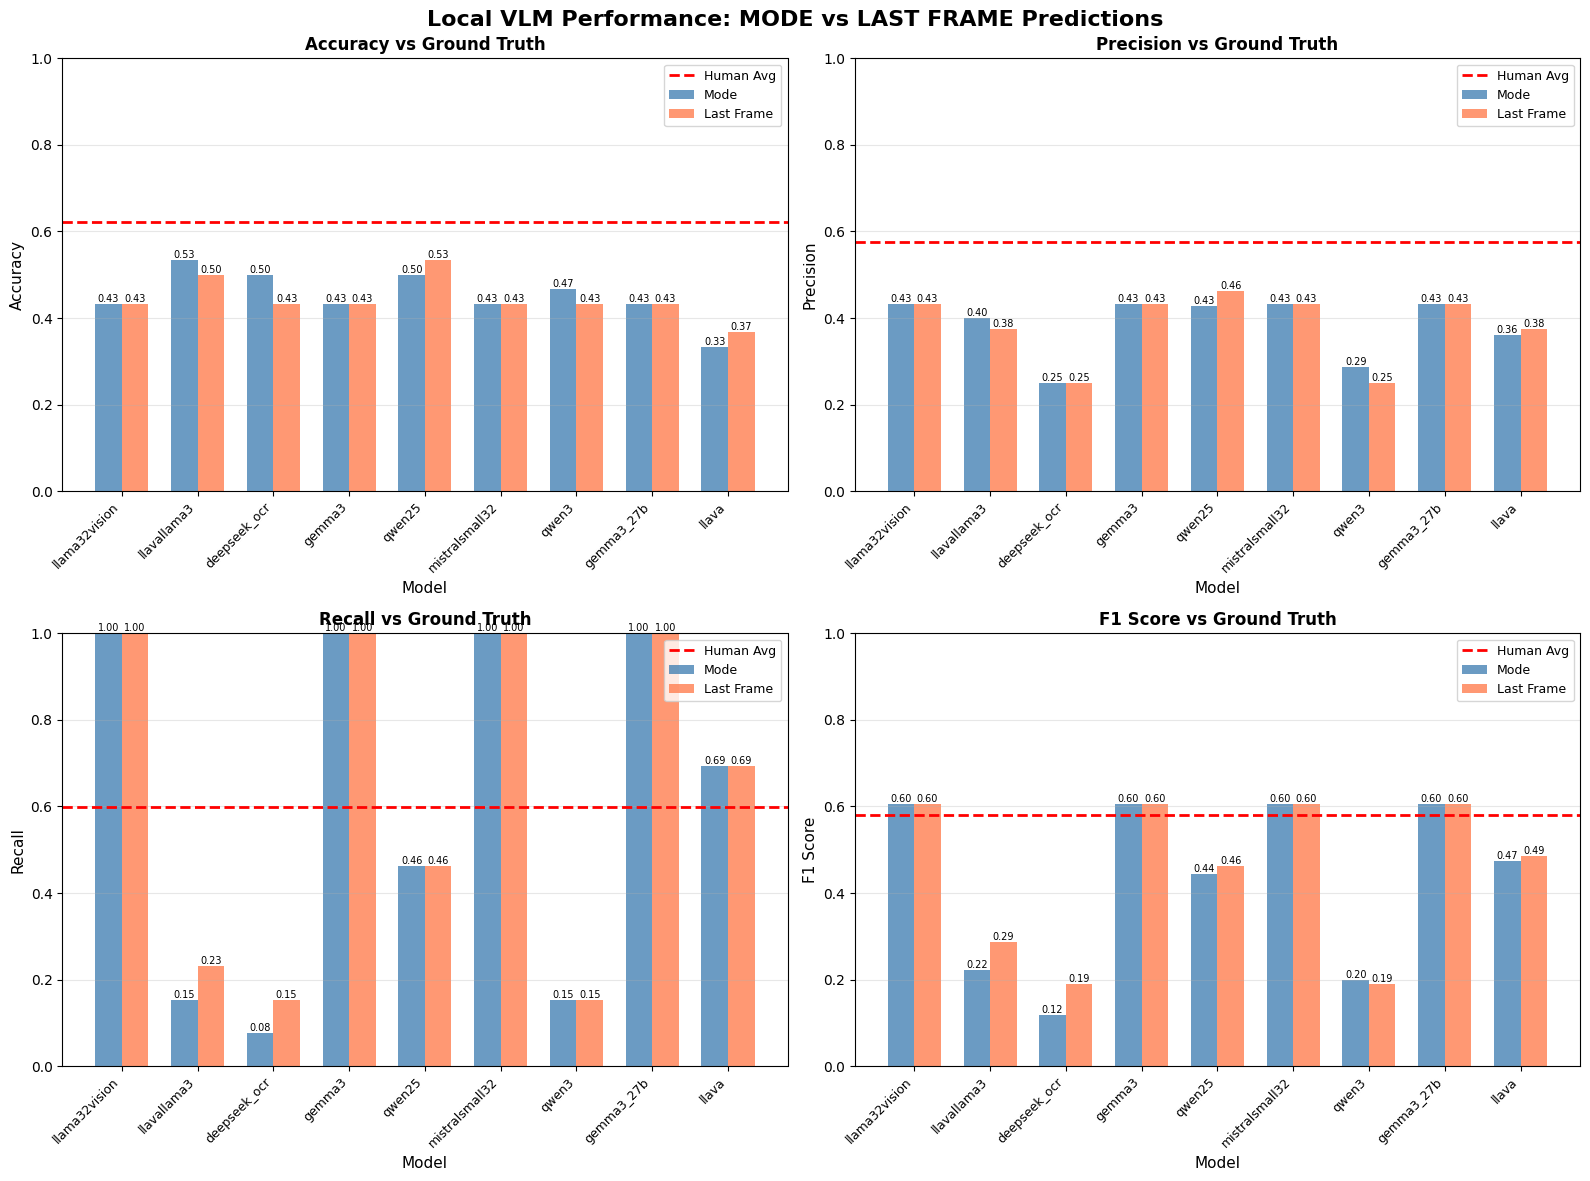


Visualization saved to 'mode_vs_last_frame_comparison.png'


In [76]:
# ===================================================================
# Visualization: MODE vs LAST FRAME Performance Comparison
# ===================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Local VLM Performance: MODE vs LAST FRAME Predictions', fontsize=16, fontweight='bold')

metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1_score']
metric_titles = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

for idx, (metric, title) in enumerate(zip(metrics_to_plot, metric_titles)):
    ax = axes[idx // 2, idx % 2]
    
    # Get data for plotting
    models = prediction_performance_mode_df['model'].tolist()
    mode_values = prediction_performance_mode_df[metric].tolist()
    last_values = prediction_performance_last_df[metric].tolist()
    
    x = np.arange(len(models))
    width = 0.35
    
    # Plot bars
    bars1 = ax.bar(x - width/2, mode_values, width, label='Mode', alpha=0.8, color='steelblue')
    bars2 = ax.bar(x + width/2, last_values, width, label='Last Frame', alpha=0.8, color='coral')
    
    # Add human baseline
    human_metric_name = metric if metric != 'f1_score' else 'f1'
    human_value = avg_human_metrics[human_metric_name]
    ax.axhline(y=human_value, color='red', linestyle='--', label='Human Avg', linewidth=2)
    
    ax.set_xlabel('Model', fontsize=11)
    ax.set_ylabel(title, fontsize=11)
    ax.set_title(f'{title} vs Ground Truth', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=45, ha='right', fontsize=9)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1)
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.2f}',
                   ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('mode_vs_last_frame_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nVisualization saved to 'mode_vs_last_frame_comparison.png'")

In [77]:
# ===================================================================
# Additional Analysis Functions (Optional)
# ===================================================================
print("\n" + "="*50)
print("Analysis Complete")
print("="*50)
print("All model evaluations have been completed.")
print("Results are saved in CSV files for further analysis.")

# Summary of saved files
print("\nSaved files:")
print("1. prediction_performance_mode.csv - MODE predictions vs ground truth")
print("2. prediction_performance_last.csv - LAST FRAME predictions vs ground truth") 
print("3. model_vs_human_agreement_mode.csv - MODE predictions vs individual humans")
print("4. model_vs_human_agreement_last.csv - LAST FRAME predictions vs individual humans")
print("5. mode_vs_last_comparison.csv - Direct comparison between methods")

# Optional: Create a final summary table
if 'prediction_performance_mode_df' in locals() and 'prediction_performance_last_df' in locals():
    print("\n" + "="*50)
    print("Final Summary Table")
    print("="*50)
    
    # Combine the key metrics
    summary_data = []
    
    for model in prediction_performance_mode_df['model'].unique():
        mode_row = prediction_performance_mode_df[prediction_performance_mode_df['model'] == model].iloc[0]
        last_row = prediction_performance_last_df[prediction_performance_last_df['model'] == model].iloc[0]
        
        summary_data.append({
            'Model': model,
            'Mode_Accuracy': mode_row['accuracy'],
            'Last_Accuracy': last_row['accuracy'],
            'Mode_F1': mode_row['f1_score'],
            'Last_F1': last_row['f1_score'],
            'Mode_Poorly_Ratio': mode_row['poorly_ratio'],
            'Last_Poorly_Ratio': last_row['poorly_ratio']
        })
    
    summary_df = pd.DataFrame(summary_data)
    print(summary_df.round(3))
    
    # Save summary
    summary_df.to_csv('final_summary.csv', index=False)
    print("\nFinal summary saved to 'final_summary.csv'")


Analysis Complete
All model evaluations have been completed.
Results are saved in CSV files for further analysis.

Saved files:
1. prediction_performance_mode.csv - MODE predictions vs ground truth
2. prediction_performance_last.csv - LAST FRAME predictions vs ground truth
3. model_vs_human_agreement_mode.csv - MODE predictions vs individual humans
4. model_vs_human_agreement_last.csv - LAST FRAME predictions vs individual humans
5. mode_vs_last_comparison.csv - Direct comparison between methods

Final Summary Table
            Model  Mode_Accuracy  Last_Accuracy  Mode_F1  Last_F1  \
0   llama32vision          0.433          0.433    0.605    0.605   
1     llavallama3          0.533          0.500    0.222    0.286   
2    deepseek_ocr          0.500          0.433    0.118    0.190   
3          gemma3          0.433          0.433    0.605    0.605   
4          qwen25          0.500          0.533    0.444    0.462   
5  mistralsmall32          0.433          0.433    0.605    0.6